# Einfluss meteorologischer Bedingungen auf die Photovoltaikerzeugung in Deutschland

**Forschungsfrage:** Unter welchen meteorologischen Bedingungen ist die auf die
installierte Leistung normierte Photovoltaikerzeugung in Deutschland am höchsten?

**These:** Die höchste normierte Photovoltaikerzeugung tritt bei hoher
Sonneneinstrahlung und moderaten Temperaturen auf. Bei sehr hohen Temperaturen
nimmt die Erzeugung trotz starker Einstrahlung wieder ab.

**Ziel:** Ein stündliches Modell prognostiziert den deutschen PV-Kapazitätsfaktor
und identifiziert Bedingungen mit erhöhtem thermischem Verlust.

Das Notebook verwendet dieselben Funktionen wie die Streamlit-App. Fehlen reale
SMARD-/DWD-Daten, läuft es mit eindeutig markierten synthetischen Demodaten.
Diese sind kein empirischer Befund.

## 1. Setup und Datenstatus

SMARD liefert realisierte Photovoltaikerzeugung und die installierte Leistung.
DWD-Stationsdaten werden deutschlandweit aggregiert. Gespeichert wird in UTC,
Kalendermerkmale werden in Europe/Berlin erzeugt.

In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from pv_weather import (
    MODEL_FEATURES,
    TARGET,
    add_features,
    estimate_module_temperature,
    load_project_data,
    predict_yield,
    train_yield_model,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

data, source = load_project_data(ROOT / "data" / "processed" / "hourly_pv_weather.csv")
IS_DEMO = source.startswith("Synthetische")
print(source)
print(f"{len(data):,} Stunden | {data.timestamp_utc.min()} bis {data.timestamp_utc.max()}")
if IS_DEMO:
    print("ACHTUNG: Alle folgenden Zahlen illustrieren nur den Workflow.")
display(data.head())

Realdaten: C:/Users/morri/PycharmProjects/BigData-Photovoltaikerzeugung/data/processed/hourly_pv_weather.csv
52,608 Stunden | 2020-01-01 00:00:00+00:00 bis 2025-12-31 23:00:00+00:00


,timestamp_utc,temperature_c,relative_humidity_pct,global_radiation_j_cm2,diffuse_radiation_j_cm2,sunshine_duration_min,solar_zenith_angle_deg,cloud_cover_oktas,wind_speed_m_s,installed_pv_capacity_mw,pv_generation_mwh
0,2020-01-01 00:00:00+00:00,1.79375,90.7500,0.0,0.0,0.0,151.053125,5.5625,2.79375,47754.0,0.0
1,2020-01-01 01:00:00+00:00,1.58125,91.0625,0.0,0.0,0.0,146.724375,5.5625,3.00625,47754.0,0.0
2,2020-01-01 02:00:00+00:00,1.35625,91.4375,0.0,0.0,0.0,139.546250,6.1250,3.00625,47754.0,0.0
3,2020-01-01 03:00:00+00:00,1.06250,92.1250,0.0,0.0,0.0,130.913750,5.1250,3.10000,47754.0,0.0
4,2020-01-01 04:00:00+00:00,1.08750,91.2500,0.0,0.0,0.0,121.681250,4.2500,2.85625,47754.0,0.0


## 2. Datenqualität und Zielvariable

Der stündliche Kapazitätsfaktor ist dimensionslos:

`PV-Erzeugung [MWh] / (installierte PV-Leistung [MW] × 1 h)`

Jahreswerte der installierten Leistung sind eine Näherung, weil der Ausbau
innerhalb des Jahres nicht vollständig abgebildet wird.

In [11]:
hourly = add_features(data)
quality = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "fehlend_n": data.isna().sum(),
    "fehlend_pct": data.isna().mean().mul(100).round(2),
    "eindeutig": data.nunique(),
})
display(quality)
print(f"Doppelte UTC-Stunden: {data['timestamp_utc'].duplicated().sum()}")
print(f"Ungültige Zielwerte: {(~hourly[TARGET].between(0, 1.2) & hourly[TARGET].notna()).sum()}")
display(hourly[["timestamp_utc", "pv_generation_mwh", "installed_pv_capacity_mw", TARGET]].head())

,dtype,fehlend_n,fehlend_pct,eindeutig
timestamp_utc,"datetime64[ns, UTC]",0,0.0,52608
temperature_c,float64,0,0.0,7434
relative_humidity_pct,float64,0,0.0,1941
global_radiation_j_cm2,float64,0,0.0,9549
diffuse_radiation_j_cm2,float64,0,0.0,5235
sunshine_duration_min,float64,0,0.0,2500
solar_zenith_angle_deg,float64,0,0.0,46258
cloud_cover_oktas,float64,2,0.0,349
wind_speed_m_s,float64,0,0.0,2595
installed_pv_capacity_mw,float64,0,0.0,6


Doppelte UTC-Stunden: 0
Ungültige Zielwerte: 0


,timestamp_utc,pv_generation_mwh,installed_pv_capacity_mw,normalized_pv_generation
0,2020-01-01 00:00:00+00:00,0.0,47754.0,0.0
1,2020-01-01 01:00:00+00:00,0.0,47754.0,0.0
2,2020-01-01 02:00:00+00:00,0.0,47754.0,0.0
3,2020-01-01 03:00:00+00:00,0.0,47754.0,0.0
4,2020-01-01 04:00:00+00:00,0.0,47754.0,0.0


## 3. Wetteraggregation und Feature Engineering

Kernmerkmale sind Global-/Diffusstrahlung, Sonnenscheindauer, Sonnenzenit,
Lufttemperatur, Feuchte, Bewölkung und Wind. Bei echten Daten werden Stationen
aktuell mit einem ungewichteten arithmetischen Mittel zu einem deutschlandweiten
Stundenwert zusammengefasst. Das ist eine Vereinfachung: Regionen mit vielen
Stationen erhalten mehr Gewicht, die regionale Verteilung der installierten
PV-Leistung wird nicht berücksichtigt und regionale Unterschiede werden
geglättet.

Die Modultemperatur ist nicht gemessen. Sie wird transparent mit einer
NOCT-artigen Näherung aus Lufttemperatur, Strahlung und Wind geschätzt:

`T_modul ≈ T_luft + 0,03125 × Einstrahlung_W/m² / (1 + 0,12 × Wind_m/s)`

In [12]:
selected = [
    "timestamp_utc", "hour", "month", "season",
    "global_radiation_j_cm2", "temperature_c", "wind_speed_m_s",
    "estimated_module_temperature_c", "thermal_stress_c", TARGET,
]
display(hourly[selected].head(24).tail())
print("Modellmerkmale:")
print("\n".join(f"• {feature}" for feature in MODEL_FEATURES))

,timestamp_utc,hour,month,season,global_radiation_j_cm2,temperature_c,wind_speed_m_s,estimated_module_temperature_c,thermal_stress_c,normalized_pv_generation
19,2020-01-01 19:00:00+00:00,20,1,Winter,0.0,0.15000,2.90625,0.15000,0.0,0.0
20,2020-01-01 20:00:00+00:00,21,1,Winter,0.0,-0.25625,2.69375,-0.25625,0.0,0.0
21,2020-01-01 21:00:00+00:00,22,1,Winter,0.0,-0.55000,2.71875,-0.55000,0.0,0.0
22,2020-01-01 22:00:00+00:00,23,1,Winter,0.0,-0.64375,2.61250,-0.64375,0.0,0.0
23,2020-01-01 23:00:00+00:00,0,1,Winter,0.0,-0.76250,2.68750,-0.76250,0.0,0.0


Modellmerkmale:
• temperature_c
• relative_humidity_pct
• global_radiation_j_cm2
• diffuse_radiation_j_cm2
• sunshine_duration_min
• solar_zenith_angle_deg
• cloud_cover_oktas
• wind_speed_m_s
• estimated_module_temperature_c
• thermal_stress_c
• radiation_thermal_interaction
• diffuse_share
• hour_sin
• hour_cos
• month_sin
• month_cos


## 4. Außentemperatur, Einstrahlung und PV-Erzeugung

Diese Darstellung entspricht der Datenexploration in der Streamlit-App.
Nachtstunden werden entfernt. Jeder Punkt verbindet die unabhängig beobachtete
Globalstrahlung mit der Luft- beziehungsweise Außentemperatur; seine Farbe zeigt
die normierte PV-Erzeugung.

Die geschätzte Modultemperatur bleibt ein Merkmal des Modells, wird hier aber
nicht als unabhängige Achse verwendet, weil sie bereits aus Lufttemperatur,
Strahlung und Wind berechnet wird. Eine Punktwolke beschreibt Zusammenhänge,
keine Kausalität.

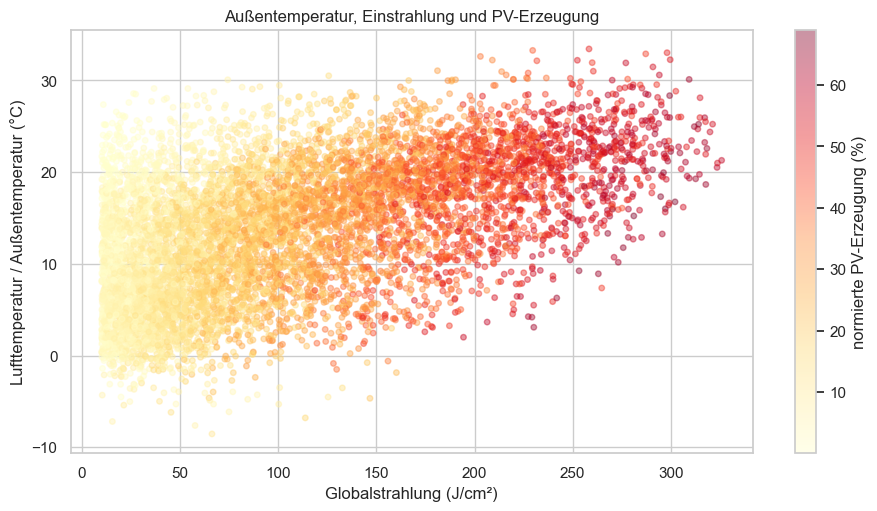

In [13]:
daylight = hourly[
    (hourly["global_radiation_j_cm2"] > 10) & hourly[TARGET].notna()
].copy()
sample = daylight.sample(min(8000, len(daylight)), random_state=42)

plt.figure(figsize=(11, 5.5))
scatter = plt.scatter(
    sample["global_radiation_j_cm2"],
    sample["temperature_c"],
    c=sample[TARGET] * 100,
    cmap="YlOrRd",
    s=16,
    alpha=.42,
)
plt.colorbar(scatter, label="normierte PV-Erzeugung (%)")
plt.xlabel("Globalstrahlung (J/cm²)")
plt.ylabel("Lufttemperatur / Außentemperatur (°C)")
plt.title("Außentemperatur, Einstrahlung und PV-Erzeugung")
plt.show()

## 5. Test der Temperaturthese bei starker Einstrahlung

Um Einstrahlung grob zu kontrollieren, werden nur Stunden im oberen
Strahlungsquartil verglichen. Saison, Sonnenstand und Wetter bleiben dennoch
mögliche Störfaktoren.

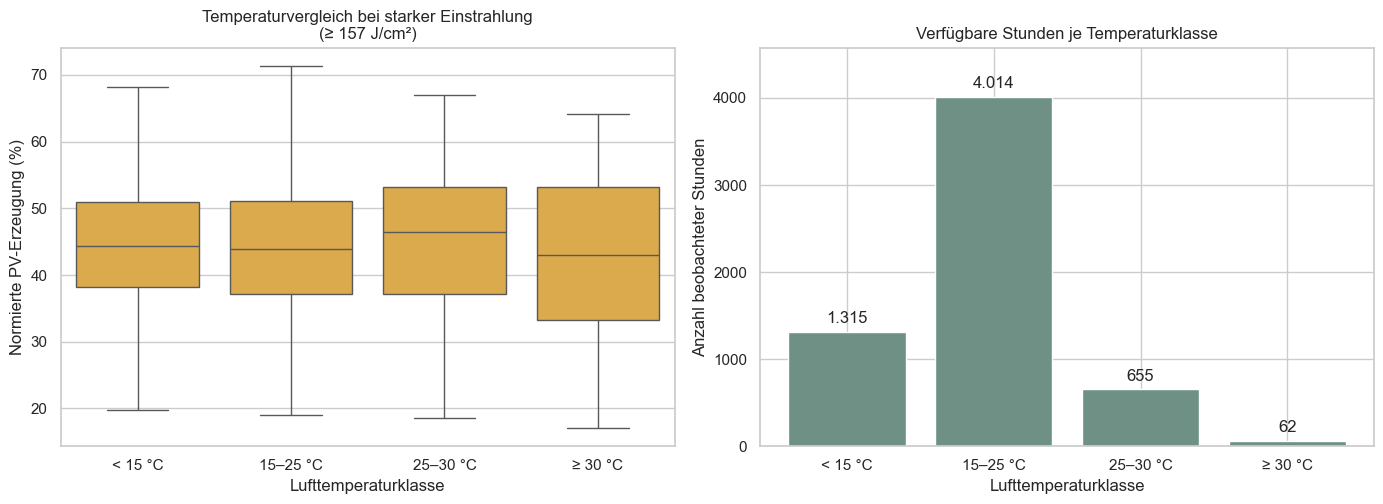

,Stunden,Mittelwert,Median
temperature_class,,,
< 15 °C,1315,44.69,44.29
15–25 °C,4014,44.00,43.83
25–30 °C,655,45.12,46.41
≥ 30 °C,62,42.64,43.00


Höchster beobachteter Median: 25–30 °C mit 46.41 %. Ab 30 °C liegt der Median um 3.40 Prozentpunkte darunter; diese Klasse umfasst 62 Stunden.


In [14]:
high_radiation_limit = daylight["global_radiation_j_cm2"].quantile(.75)
strong_sun = daylight[daylight["global_radiation_j_cm2"] >= high_radiation_limit].copy()
strong_sun["temperature_class"] = pd.cut(
    strong_sun["temperature_c"],
    [-30, 15, 25, 30, 60],
    labels=["< 15 °C", "15–25 °C", "25–30 °C", "≥ 30 °C"],
)
temperature_summary = strong_sun.groupby("temperature_class", observed=True)[TARGET].agg(
    Stunden="size", Mittelwert="mean", Median="median"
)
temperature_summary[["Mittelwert", "Median"]] *= 100
strong_sun["Normierte PV-Erzeugung (%)"] = strong_sun[TARGET] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
sns.boxplot(
    data=strong_sun.sample(min(8000, len(strong_sun)), random_state=42),
    x="temperature_class",
    y="Normierte PV-Erzeugung (%)",
    color="#F2B134",
    showfliers=False,
    ax=axes[0],
)
axes[0].set_xlabel("Lufttemperaturklasse")
axes[0].set_ylabel("Normierte PV-Erzeugung (%)")
axes[0].set_title(
    f"Temperaturvergleich bei starker Einstrahlung\n"
    f"(≥ {high_radiation_limit:.0f} J/cm²)"
)

count_bars = axes[1].bar(
    temperature_summary.index.astype(str),
    temperature_summary["Stunden"],
    color="#6F9185",
)
axes[1].bar_label(
    count_bars,
    labels=[f"{int(value):,}".replace(",", ".") for value in temperature_summary["Stunden"]],
    padding=4,
)
axes[1].set_xlabel("Lufttemperaturklasse")
axes[1].set_ylabel("Anzahl beobachteter Stunden")
axes[1].set_title("Verfügbare Stunden je Temperaturklasse")
axes[1].set_ylim(0, temperature_summary["Stunden"].max() * 1.14)
fig.tight_layout()
plt.show()

display(temperature_summary.round(2))

best_class = temperature_summary["Median"].idxmax()
best_median = temperature_summary.loc[best_class, "Median"]
hot_median = temperature_summary.loc["≥ 30 °C", "Median"]
hot_hours = int(temperature_summary.loc["≥ 30 °C", "Stunden"])
print(
    f"Höchster beobachteter Median: {best_class} mit {best_median:.2f} %. "
    f"Ab 30 °C liegt der Median um {best_median - hot_median:.2f} Prozentpunkte "
    f"darunter; diese Klasse umfasst {hot_hours} Stunden."
)

## 6. Zeitlich ehrliches Prognosemodell

Die ersten 80 % der vollständigen Beobachtungen bilden das Training, die
neuesten 20 % einen zusammenhängenden Test. Das verhindert zufälliges
Vermischen von Vergangenheit und Zukunft.

Die Kennzahlen entsprechen dem Bereich „Modellgüte“ in der Streamlit-App.
MAE und RMSE werden in Prozentpunkten angegeben; R² ist keine Trefferquote.

In [15]:
bundle = train_yield_model(data)
metrics = pd.DataFrame(
    {
        "Gradient Boosting": [
            bundle.metrics["model_mae"] * 100,
            bundle.metrics["model_rmse"] * 100,
            bundle.metrics["model_r2"],
        ],
        "Median-Baseline": [
            bundle.metrics["baseline_mae"] * 100,
            bundle.metrics["baseline_rmse"] * 100,
            bundle.metrics["baseline_r2"],
        ],
    },
    index=["MAE (Prozentpunkte)", "RMSE (Prozentpunkte)", "R²"],
)
print(f"Zeitlicher Test beginnt: {bundle.split_timestamp}")
display(metrics.round(3))

Zeitlicher Test beginnt: 2024-10-19 14:00:00+00:00


,Gradient Boosting,Median-Baseline
MAE (Prozentpunkte),1.151,8.572
RMSE (Prozentpunkte),2.411,15.941
R²,0.969,-0.357


## 7. Prognose eines meteorologischen Szenarios

Dieses Referenzszenario verwendet dieselben Standardwerte wie die
Streamlit-App. Die installierte PV-Leistung skaliert nur die absolute Erzeugung;
die normierte Modellprognose bleibt unverändert.

In [16]:
SCENARIO_REFERENCE_DAY = pd.Timestamp("2024-07-01")
SCENARIO_REFERENCE_HOUR = 13


def solar_zenith(day, hour, latitude_deg=51.0):
    day_of_year = pd.Timestamp(day).dayofyear
    declination = np.deg2rad(
        23.44 * np.sin(2 * np.pi * (284 + day_of_year) / 365)
    )
    latitude = np.deg2rad(latitude_deg)
    hour_angle = np.deg2rad(15 * (hour - 12))
    cosine = (
        np.sin(latitude) * np.sin(declination)
        + np.cos(latitude) * np.cos(declination) * np.cos(hour_angle)
    )
    return float(np.rad2deg(np.arccos(np.clip(cosine, -1, 1))))


def scenario_frame(
    day=SCENARIO_REFERENCE_DAY,
    hour=SCENARIO_REFERENCE_HOUR,
    radiation=270.0,
    temperature=25.0,
    cloud_cover=2.0,
    wind_speed=3.0,
    humidity=55.0,
):
    timestamp = (
        pd.Timestamp(day)
        .replace(hour=hour)
        .tz_localize("Europe/Berlin", ambiguous=True, nonexistent="shift_forward")
        .tz_convert("UTC")
    )
    diffuse_share = np.clip(0.14 + 0.075 * cloud_cover, 0.12, 0.82)
    sunshine = np.clip(
        60 * (radiation / 330) * (1 - cloud_cover / 9),
        0,
        60,
    )
    return pd.DataFrame(
        {
            "timestamp_utc": [timestamp],
            "temperature_c": [temperature],
            "relative_humidity_pct": [humidity],
            "global_radiation_j_cm2": [radiation],
            "diffuse_radiation_j_cm2": [radiation * diffuse_share],
            "sunshine_duration_min": [sunshine],
            "solar_zenith_angle_deg": [solar_zenith(day, hour)],
            "cloud_cover_oktas": [cloud_cover],
            "wind_speed_m_s": [wind_speed],
        }
    )


current_scenario = scenario_frame()
current_prediction = predict_yield(bundle, current_scenario).iloc[0]
current_module_temperature = estimate_module_temperature(
    current_scenario["temperature_c"],
    current_scenario["global_radiation_j_cm2"],
    current_scenario["wind_speed_m_s"],
)[0]
installed_capacity_mw = 90_000

scenario_result = pd.DataFrame(
    {
        "Wert": [
            current_prediction["normalized_pv_prediction"] * 100,
            current_prediction["lower_80"] * 100,
            current_prediction["upper_80"] * 100,
            current_module_temperature,
            current_prediction["normalized_pv_prediction"]
            * installed_capacity_mw,
        ],
        "Einheit": [
            "%",
            "%",
            "%",
            "°C",
            "MW beziehungsweise MWh in einer Stunde",
        ],
    },
    index=[
        "Prognostizierte normierte PV-Erzeugung",
        "Untere Grenze des empirischen 80-%-Intervalls",
        "Obere Grenze des empirischen 80-%-Intervalls",
        "Geschätzte Modultemperatur",
        "Geschätzte Erzeugung bei 90.000 MW installierter Leistung",
    ],
)
display(scenario_result.round(2))

,Wert,Einheit
Prognostizierte normierte PV-Erzeugung,56.25,%
Untere Grenze des empirischen 80-%-Intervalls,52.54,%
Obere Grenze des empirischen 80-%-Intervalls,56.53,%
Geschätzte Modultemperatur,42.23,°C
Geschätzte Erzeugung bei 90.000 MW installierter Leistung,50626.34,MW beziehungsweise MWh in einer Stunde


## 8. Thermischer Effekt bei gleicher Einstrahlung

Die Lufttemperatur wird wie im App-Tab „Thermischer Effekt“ von −5 bis 42 °C
variiert. Globalstrahlung, Bewölkung, Wind, Luftfeuchtigkeit und Kalenderwerte
bleiben konstant. Die Kurve zeigt eine Modellreaktion und keinen isolierten
Kausalnachweis.

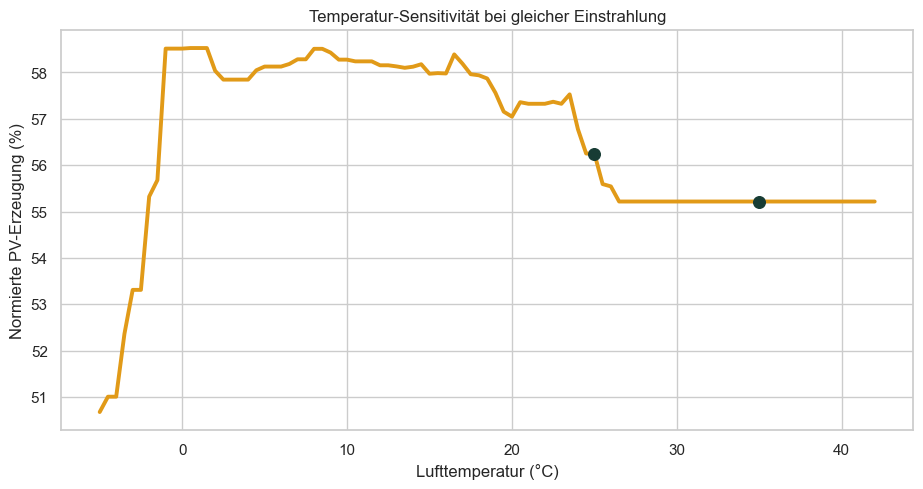

,Lufttemperatur (°C),Geschätzte Modultemperatur (°C),Normierte PV-Erzeugung (%)
Referenz 25 °C,25.0,42.23,56.25
Referenz 35 °C,35.0,52.23,55.22


Modellbasierter Rückgang von 25 auf 35 °C: 1.04 Prozentpunkte.


In [17]:
temperatures = np.linspace(-5, 42, 95)
curve_input = pd.concat(
    [scenario_frame(temperature=float(value)) for value in temperatures],
    ignore_index=True,
)
curve_prediction = predict_yield(bundle, curve_input)
curve_data = pd.DataFrame(
    {
        "Lufttemperatur (°C)": temperatures,
        "Geschätzte Modultemperatur (°C)": estimate_module_temperature(
            temperatures,
            np.full_like(temperatures, 270.0),
            np.full_like(temperatures, 3.0),
        ),
        "Normierte PV-Erzeugung (%)": (
            curve_prediction["normalized_pv_prediction"].to_numpy() * 100
        ),
    }
)
row_25 = curve_data.iloc[
    int(np.abs(curve_data["Lufttemperatur (°C)"] - 25).argmin())
]
row_35 = curve_data.iloc[
    int(np.abs(curve_data["Lufttemperatur (°C)"] - 35).argmin())
]

plt.figure(figsize=(11, 5.2))
plt.plot(
    curve_data["Lufttemperatur (°C)"],
    curve_data["Normierte PV-Erzeugung (%)"],
    color="#E19A18",
    linewidth=2.8,
)
plt.scatter(
    [row_25["Lufttemperatur (°C)"], row_35["Lufttemperatur (°C)"]],
    [
        row_25["Normierte PV-Erzeugung (%)"],
        row_35["Normierte PV-Erzeugung (%)"],
    ],
    color="#173C34",
    s=70,
    zorder=3,
)
plt.xlabel("Lufttemperatur (°C)")
plt.ylabel("Normierte PV-Erzeugung (%)")
plt.title("Temperatur-Sensitivität bei gleicher Einstrahlung")
plt.show()

thermal_reference = pd.DataFrame(
    {
        "Lufttemperatur (°C)": [
            row_25["Lufttemperatur (°C)"],
            row_35["Lufttemperatur (°C)"],
        ],
        "Geschätzte Modultemperatur (°C)": [
            row_25["Geschätzte Modultemperatur (°C)"],
            row_35["Geschätzte Modultemperatur (°C)"],
        ],
        "Normierte PV-Erzeugung (%)": [
            row_25["Normierte PV-Erzeugung (%)"],
            row_35["Normierte PV-Erzeugung (%)"],
        ],
    },
    index=["Referenz 25 °C", "Referenz 35 °C"],
)
display(thermal_reference.round(2))
print(
    "Modellbasierter Rückgang von 25 auf 35 °C: "
    f"{row_25['Normierte PV-Erzeugung (%)'] - row_35['Normierte PV-Erzeugung (%)']:.2f} "
    "Prozentpunkte."
)

## 9. Aktuelles Szenario und Top-2-%-Bedingungen

„Optimal“ bezeichnet die Medianbedingungen der besten 2 % beobachteten Stunden.
Das ist ein beobachtungsnaher Vergleich und kein technisch garantiertes
Anlagenoptimum.

,Normierte PV-Erzeugung (%)
Aktuelles Szenario,56.25
Top-2-%-Bedingungen,57.14
Differenz zu den Top-2-%-Bedingungen,-0.89


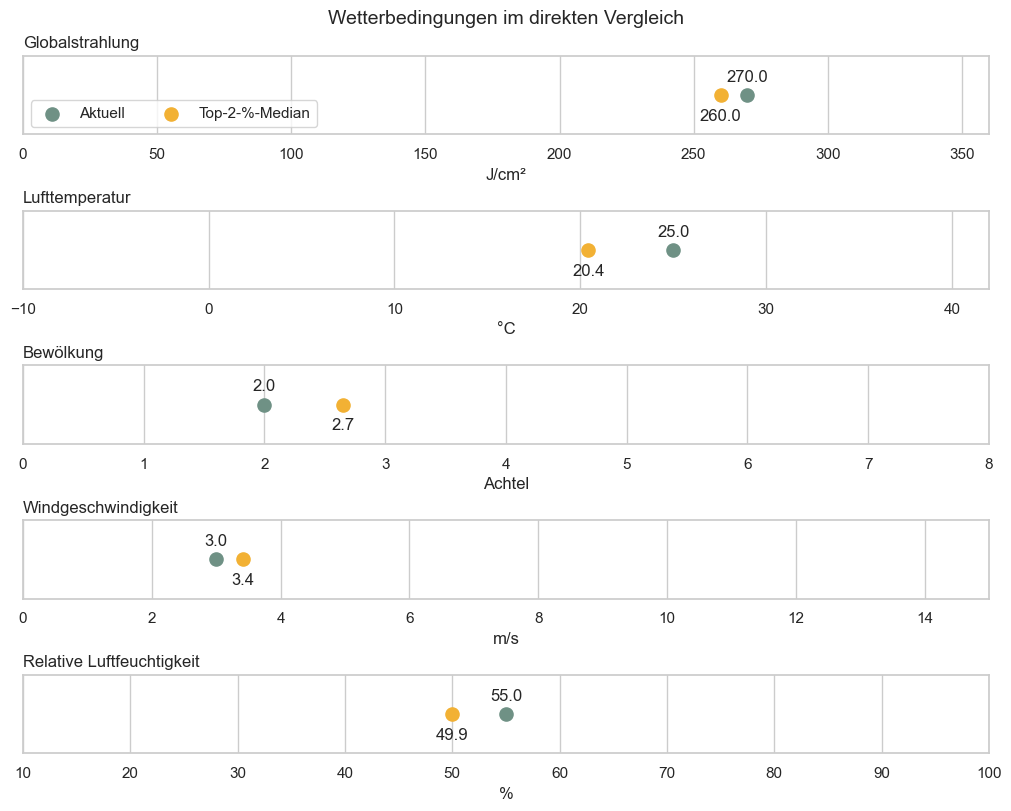

In [18]:
top = hourly.nlargest(max(50, int(len(hourly) * .02)), TARGET)
optimal_defaults = {
    column: float(top[column].median())
    for column in [
        "temperature_c",
        "relative_humidity_pct",
        "global_radiation_j_cm2",
        "cloud_cover_oktas",
        "wind_speed_m_s",
    ]
}
optimal_scenario = scenario_frame(
    day=pd.Timestamp("2024-06-21"),
    radiation=optimal_defaults["global_radiation_j_cm2"],
    temperature=optimal_defaults["temperature_c"],
    cloud_cover=optimal_defaults["cloud_cover_oktas"],
    wind_speed=optimal_defaults["wind_speed_m_s"],
    humidity=optimal_defaults["relative_humidity_pct"],
)
optimal_prediction = predict_yield(bundle, optimal_scenario).iloc[0]

yield_comparison = pd.DataFrame(
    {
        "Normierte PV-Erzeugung (%)": [
            current_prediction["normalized_pv_prediction"] * 100,
            optimal_prediction["normalized_pv_prediction"] * 100,
            (
                current_prediction["normalized_pv_prediction"]
                - optimal_prediction["normalized_pv_prediction"]
            )
            * 100,
        ]
    },
    index=[
        "Aktuelles Szenario",
        "Top-2-%-Bedingungen",
        "Differenz zu den Top-2-%-Bedingungen",
    ],
)
display(yield_comparison.round(2))

condition_specs = [
    ("Globalstrahlung", "J/cm²", 0, 360, 270.0, optimal_defaults["global_radiation_j_cm2"]),
    ("Lufttemperatur", "°C", -10, 42, 25.0, optimal_defaults["temperature_c"]),
    ("Bewölkung", "Achtel", 0, 8, 2.0, optimal_defaults["cloud_cover_oktas"]),
    ("Windgeschwindigkeit", "m/s", 0, 15, 3.0, optimal_defaults["wind_speed_m_s"]),
    ("Relative Luftfeuchtigkeit", "%", 10, 100, 55.0, optimal_defaults["relative_humidity_pct"]),
]
fig, axes = plt.subplots(len(condition_specs), 1, figsize=(10, 8), constrained_layout=True)
for index, (label, unit, minimum, maximum, current_value, optimal_value) in enumerate(
    condition_specs
):
    axis = axes[index]
    axis.scatter(current_value, 0, s=90, color="#6F9185", label="Aktuell")
    axis.scatter(optimal_value, 0, s=90, color="#F2B134", label="Top-2-%-Median")
    axis.set_xlim(minimum, maximum)
    axis.set_yticks([])
    axis.set_xlabel(unit)
    axis.set_title(label, loc="left")
    axis.annotate(
        f"{current_value:.1f}",
        (current_value, 0),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
    )
    axis.annotate(
        f"{optimal_value:.1f}",
        (optimal_value, 0),
        xytext=(0, -18),
        textcoords="offset points",
        ha="center",
    )
axes[0].legend(loc="lower left", ncol=2)
fig.suptitle("Wetterbedingungen im direkten Vergleich", fontsize=14)
plt.show()

## 10. Fazit und Grenzen

Die Forschungsfrage wird über das Zusammenspiel von Einstrahlung,
Außentemperatur, geschätzter Modultemperatur und normierter PV-Erzeugung
beantwortet. Entscheidend ist der Temperaturvergleich bei ähnlicher
Einstrahlung: Eine über alle Strahlungsstärken gemischte Punktwolke kann den
thermischen Effekt durch den dominanten positiven Strahlungseffekt verdecken.

Eine empirische Schlussfolgerung ist nur zulässig, wenn oben Realdaten
ausgewiesen sind.

Wichtige Grenzen:

- Das ungewichtete Stationsmittel approximiert das Wetter der räumlich
  verteilten PV-Flotte. Regionen mit vielen Stationen zählen stärker, regionale
  PV-Leistungsunterschiede bleiben unberücksichtigt und fehlende Stationswerte
  können die Zusammensetzung des Mittels verändern.
- Jährliche Kapazitätswerte bilden unterjährigen Ausbau nicht ab.
- Die Modultemperatur wird nicht gemessen, sondern aus Lufttemperatur,
  horizontaler Globalstrahlung und Wind angenähert.
- Anlagenneigung, Ausrichtung, Schnee, Verschattung, Abregelung und technische
  Verfügbarkeit fehlen.
- Gruppenvergleiche und Modellreaktionen sind keine Kausalnachweise.

Das Notebook dokumentiert damit dieselben zentralen Ansichten wie die
Streamlit-App: Datenexploration, zeitliche Modellgüte, Prognoseszenario,
thermische Sensitivität und den Vergleich mit den besten beobachteten Stunden.